In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import rc_context
from multiprocessing import Pool
sc.settings.verbosity = 3
import os 
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.sans-serif'] = 'Arial'
sc.set_figure_params(dpi=50, dpi_save=300, vector_friendly=True)
sns.set_style('white', {'axes.grid' : False})
def vector(on=False):
    if on:
        sc.set_figure_params(dpi=50, dpi_save=300, vector_friendly=False)
    else:
        sc.set_figure_params(dpi=50, dpi_save=300, vector_friendly=True)
vector(False)

In [3]:
adata=sc.read_h5ad('/home/lixinxing/IBD/data_sc/soupX/soupX_new/adata_sc_4.h5ad')

In [4]:
tmpdf = adata.obs[['batch','group']].drop_duplicates()

In [5]:
adata.obs['sample'] = pd.Categorical(adata.obs['sample'], categories= list(tmpdf.sort_values(['group','batch'])['batch']),ordered=True)

In [6]:
tmpdf.sort_values(['group','batch'])

,batch,group
AAACCCAAGGTGCTGA-1-A0060A1,A0060A1,Nonresponder
AAACCCAAGGAGAGGC-1-B0161A1,B0161A1,Nonresponder
AAACCCAAGAGTTGAT-1-B0163A1,B0163A1,Nonresponder
AAACCCAAGCGGACAT-1-B0225A1,B0225A1,Nonresponder
AAACCCAAGACGCCCT-1-B0230A1,B0230A1,Nonresponder
AAACCCAAGATACGAT-1-L1EHH2200212,L1EHH2200212,Nonresponder
AAACCCAAGAGAGGTA-1-A0070A1,A0070A1,Responder
AAACCCAAGGTGGGTT-1-A0079A1,A0079A1,Responder
AAACCCACAACAAAGT-1-A013B,A013B,Responder
AAACCCAAGAGTATAC-1-A043A,A043A,Responder


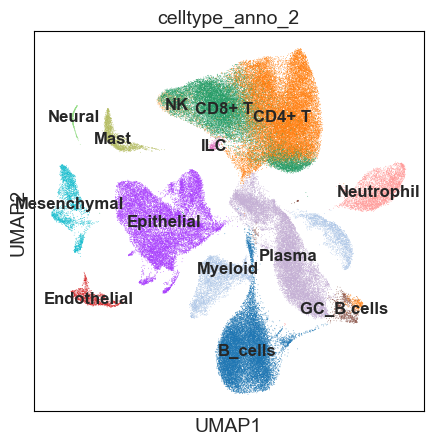

In [7]:
fig,ax = plt.subplots(figsize = (5,5))
sc.pl.umap(adata ,color = 'celltype_anno_2', legend_loc="on data",legend_fontsize = 12,ax = ax ,show =False)
fig.show()

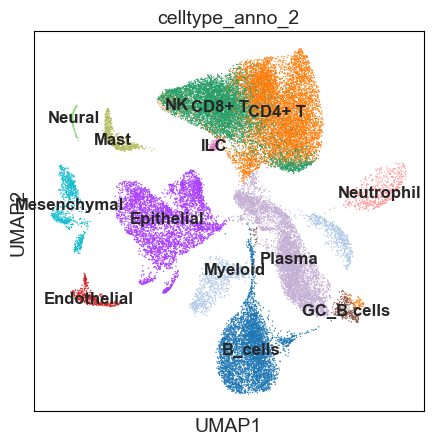

In [8]:
fig,ax = plt.subplots(figsize = (5,5))
sc.pl.umap(adata[adata.obs['group'] == 'Responder'] ,color = 'celltype_anno_2', legend_loc="on data",legend_fontsize = 12,ax = ax ,show =False)
fig.show()

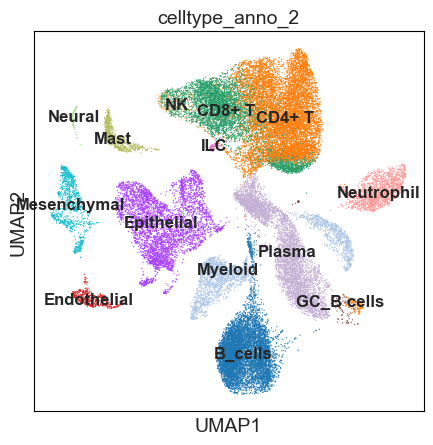

In [9]:
fig,ax = plt.subplots(figsize = (5,5))
sc.pl.umap(adata[adata.obs['group'] == 'Nonresponder'] ,color = 'celltype_anno_2', legend_loc="on data",legend_fontsize = 12,ax = ax ,show =False)
fig.show()

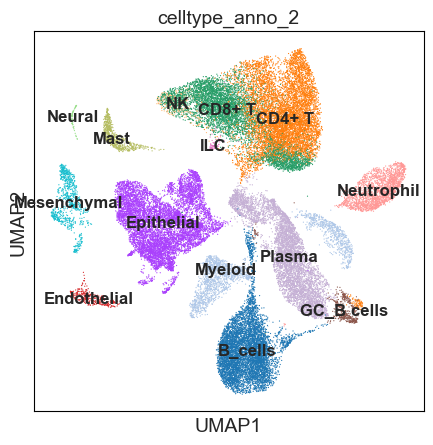

In [10]:
fig,ax = plt.subplots(figsize = (5,5))
sc.pl.umap(adata[adata.obs['group'] == 'Untreated'] ,color = 'celltype_anno_2', legend_loc="on data",legend_fontsize = 12,ax = ax ,show =False)
fig.show()

In [24]:
tadata = sc.read_h5ad('/home/lixinxing/IBD/data_sc/soupX/soupX_new/seurat/T_2.h5ad')

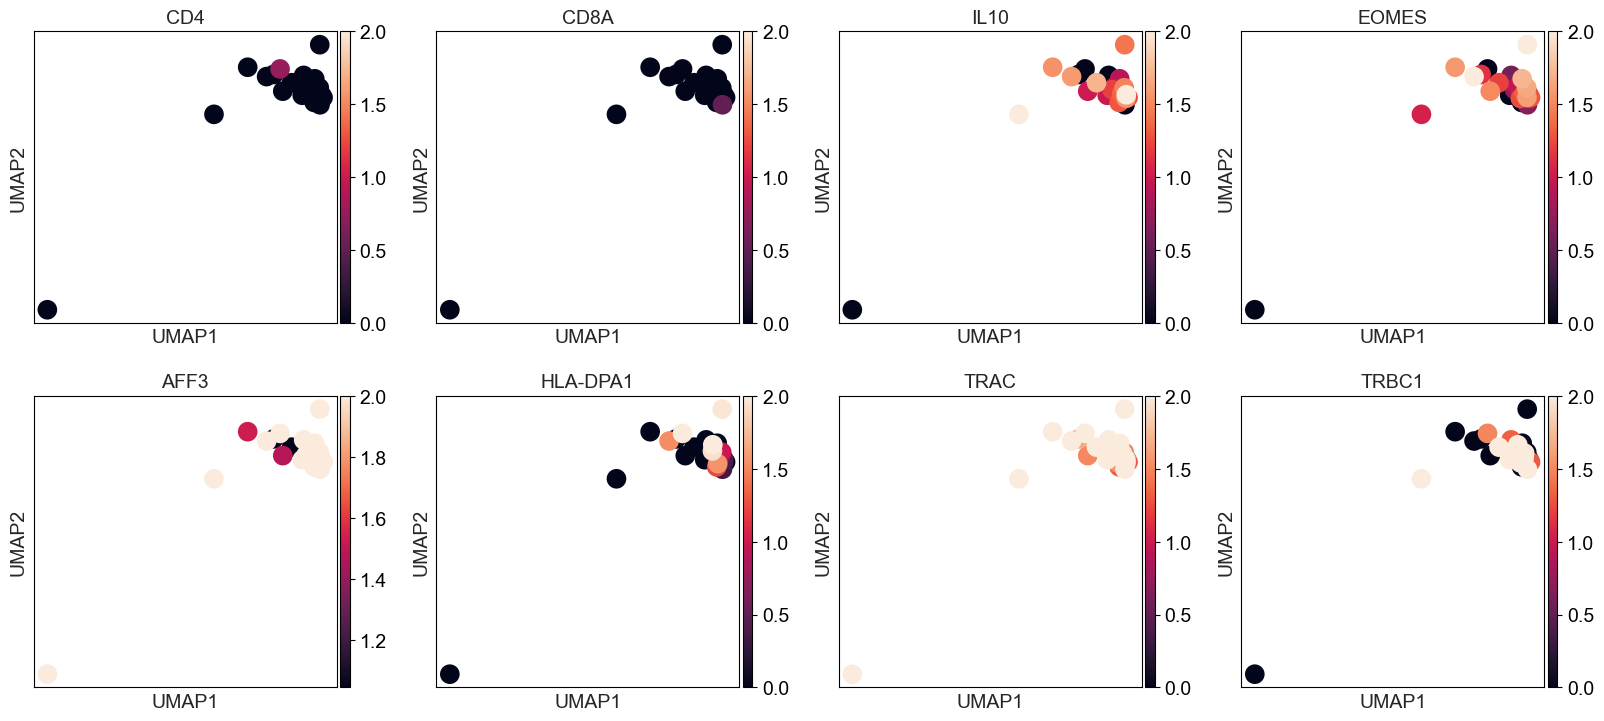

In [25]:
sc.pl.umap(tadata[tadata.obs['subtype_anno'] == 'IL10+ DNT'] , color = ['CD4','CD8A','IL10','EOMES','AFF3','HLA-DPA1','TRAC','TRBC1'],s = 800,vmax = 2)

In [26]:
public_1_tadata = "/home/lixinxing/IBD/publicdata/Data1/public_T_anno.h5ad"
public_1_tadata = sc.read_h5ad(public_1_tadata)
public_2_tadata = "/home/lixinxing/IBD/publicdata/2025_07_18/Data2/T_public_2_ano.h5ad"
public_2_tadata = sc.read_h5ad(public_2_tadata)
public_4_tadata = "/home/lixinxing/IBD/publicdata/2025_07_18/Data4/T_public_4_ano.h5ad"
public_4_tadata = sc.read_h5ad(public_4_tadata)
public_4_tadata.obs['dataset'] = '4'
public_2_tadata.obs['dataset'] = '2'
public_tmp_tadata = sc.concat([public_4_tadata,public_2_tadata],join = 'outer')
public_4_tadata = public_tmp_tadata[public_tmp_tadata.obs['dataset'] == '4'].copy()

/home/liuyi/miniconda3/envs/spatial/lib/python3.9/site-packages/anndata/_core/merge.py:1362: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(


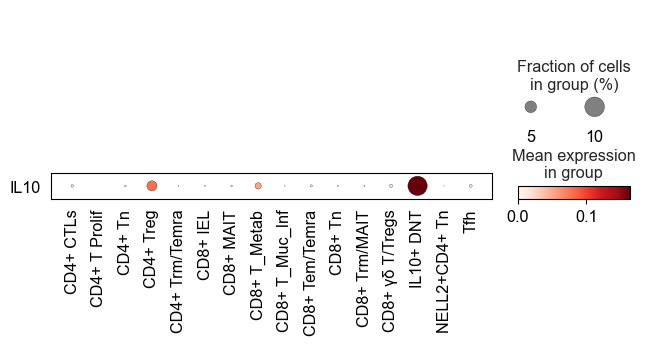

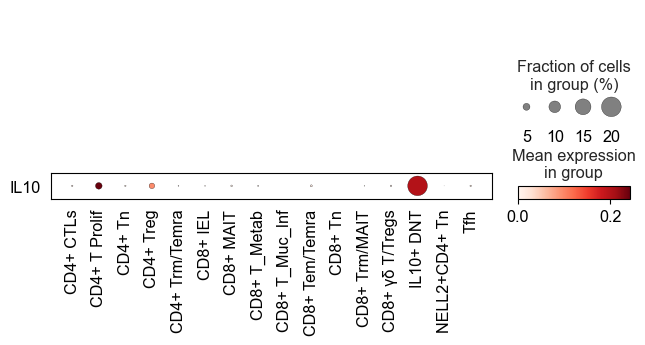

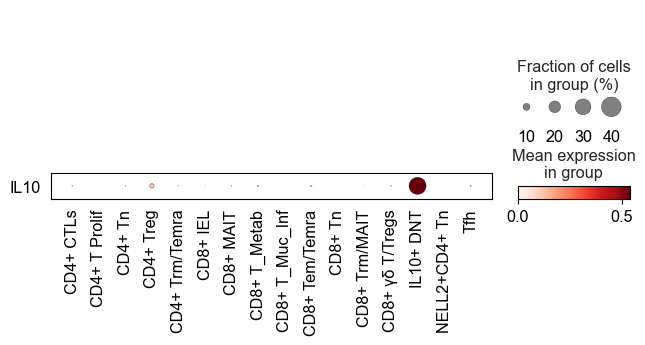

In [34]:
sc.pl.dotplot(public_1_tadata,var_names = 'IL10',groupby = 'subtype',swap_axes=True)
sc.pl.dotplot(public_2_tadata,var_names = 'IL10',groupby = 'subtype',swap_axes=True)
sc.pl.dotplot(public_4_tadata,var_names = 'IL10',groupby = 'subtype',swap_axes=True)

In [38]:
spdata = sc.read_h5ad('/home/lixinxing/IBD/data_sp/2025_05_16_code/adata_merge_3_sub_newname.h5ad')

In [39]:
spdata.obs['ordergroup'] = pd.Categorical(spdata.obs['group'],ordered= True, categories = ['Untreated','Nonresponder','Responder'])

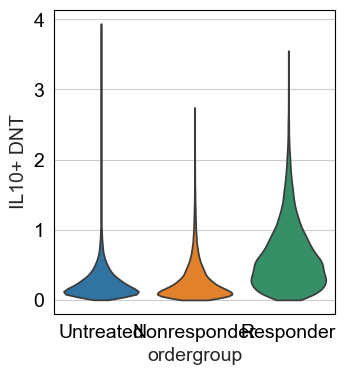

In [41]:
sc.pl.violin(spdata,keys = 'IL10+ DNT',groupby = 'ordergroup',stripplot = False)

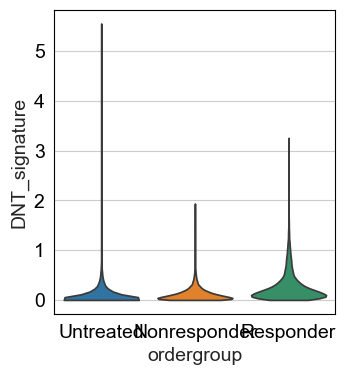

In [40]:
sc.pl.violin(spdata,keys = 'DNT_signature',groupby = 'ordergroup',stripplot = False)

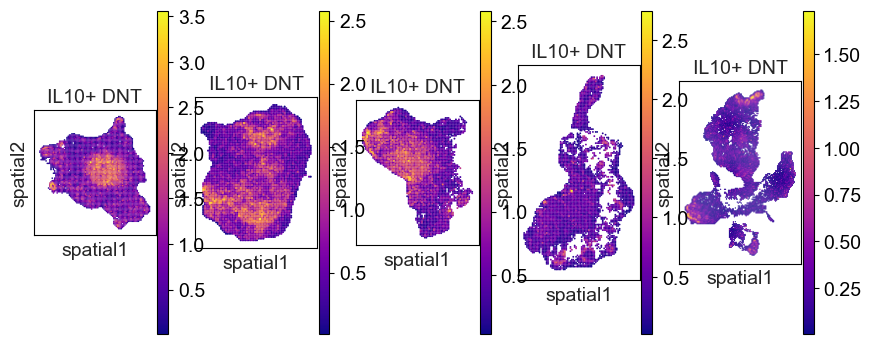

In [44]:
fig,axs = plt.subplots(1,5,figsize = (10, 5))
m=0
for sample in ['B03501E1_1','B03501E2_1','B03501C3_1','Y00860K1_1','B03501C4_2']:
    subadata = spdata[spdata.obs['batch'] == sample]
    spot_size = 65
    sc.pl.spatial(subadata,color=['IL10+ DNT'],spot_size = spot_size,cmap = 'plasma',show = False, ax = axs[m] )
    m+=1

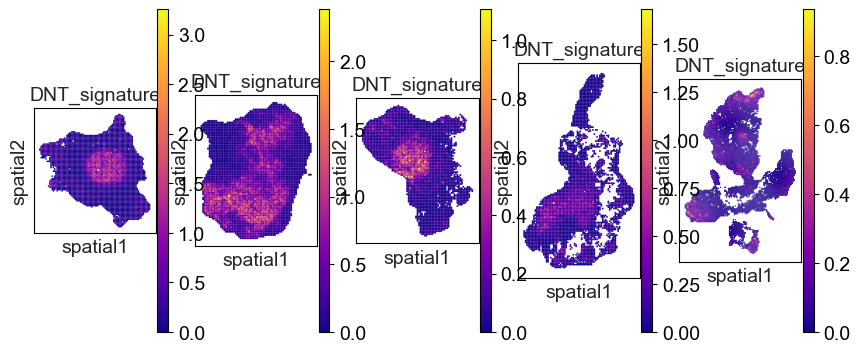

In [47]:
fig,axs = plt.subplots(1,5,figsize = (10, 5))
m=0
for sample in ['B03501E1_1','B03501E2_1','B03501C3_1','Y00860K1_1','B03501C4_2']:
    subadata = spdata[spdata.obs['batch'] == sample]
    spot_size = 65
    sc.pl.spatial(subadata,color=['DNT_signature'],spot_size = spot_size,cmap = 'plasma',show = False, ax = axs[m] )
    m+=1

In [52]:
# extend

In [53]:
category_dict = {
    'Identity':"CD3E, CD4, CD8A, CD8B, TRBC1".split(', '),
    'Exclude Treg':"FOXP3, IKZF2".split(', '),
    'Exclude Tr1':"MAF, AHR".split(', '),
    'Exclude exhausted CD8':"TOX, NR4A1".split(', '),
    'Exclude γδ / innate-like':"TRDC, ZBTB16".split(', '),
    'Immune Suppression':  "IL10,TIGIT,FOXP1,CD38".split(','),
    'Effector/Activation':"GZMK, CRTAM, PHLDA1, SLAMF7, CD27".split(', '),
    'Migration':"PECAM1, CD44, CNR2, S1PR4, GPR183".split(', '),
    'Metabolism':"FABP5, ANXA2, PIP4K2A, ACTG1".split(', '),
    'Antigen Presentation':"HLA-DRA, HLA-DRB1, CD74, CLEC2D".split(', '),
    "Transcriptional Regulation":"EOMES, AFF3, RUNX2, BACH2".split(', '),
    "Signal Regulation":"PTPRJ, PIK3R5".split(', ')
}


gene2cat = {g: cat for cat, genes in category_dict.items() for g in genes}

In [ ]:
sc.pl.matrixplot(adata = tadata, var_names = category_dict,groupby = 'subtype_anno',standard_scale='var',cmap = 'Reds',save='geneidentity.pdf')

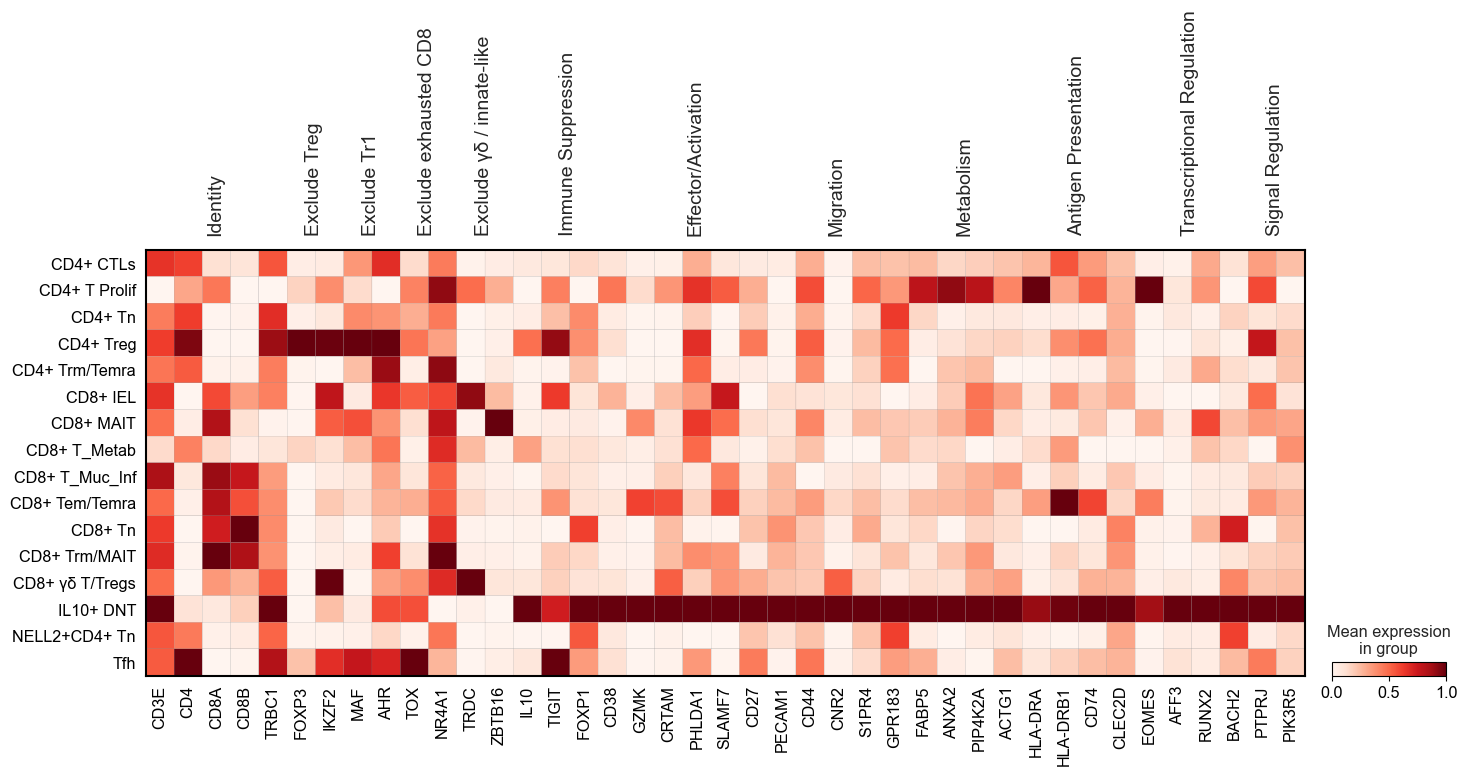

In [56]:
sc.pl.matrixplot(adata = public_1_tadata, var_names = category_dict,groupby = 'subtype',cmap = 'Reds',standard_scale = 'var')

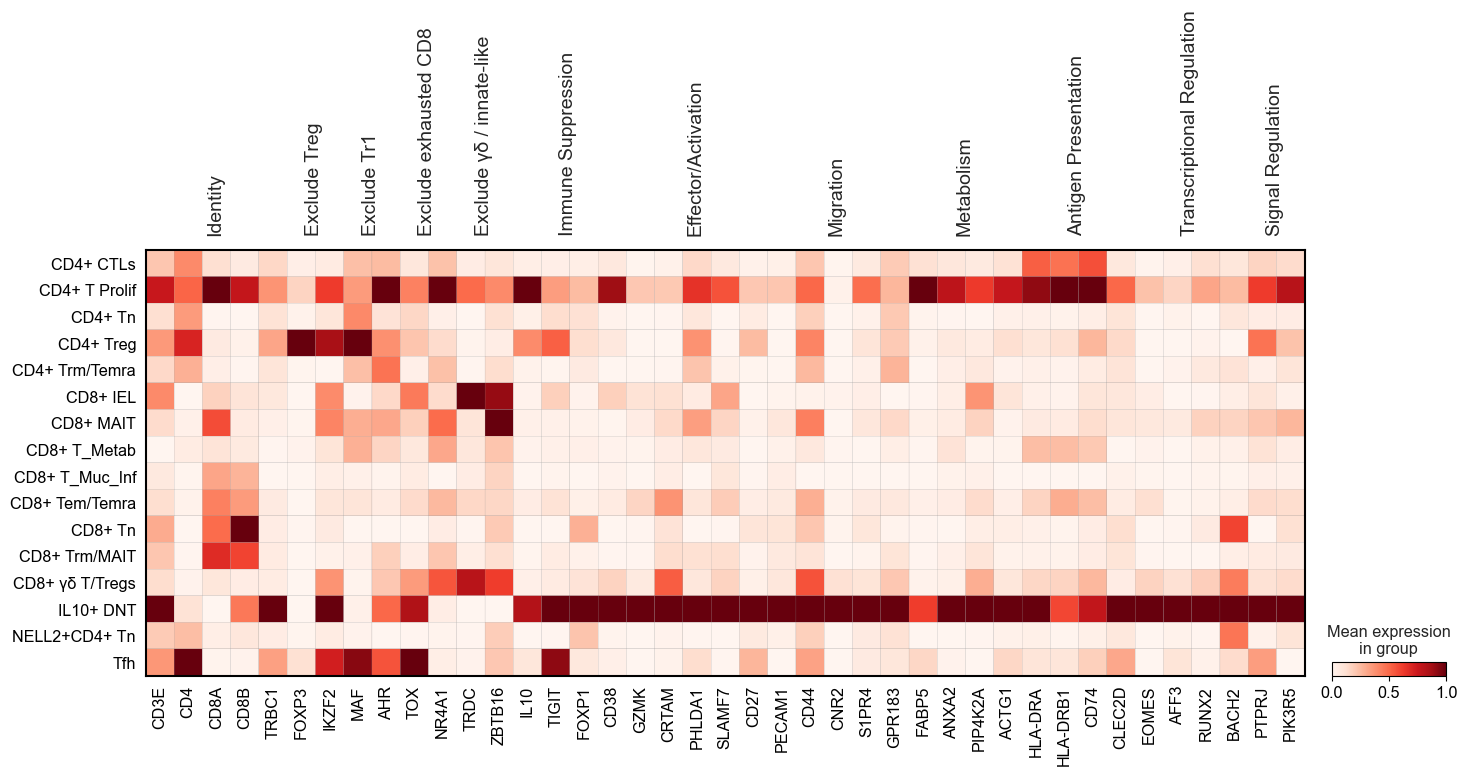

In [57]:
sc.pl.matrixplot(adata = public_2_tadata, var_names = category_dict,groupby = 'subtype',cmap = 'Reds',standard_scale = 'var')

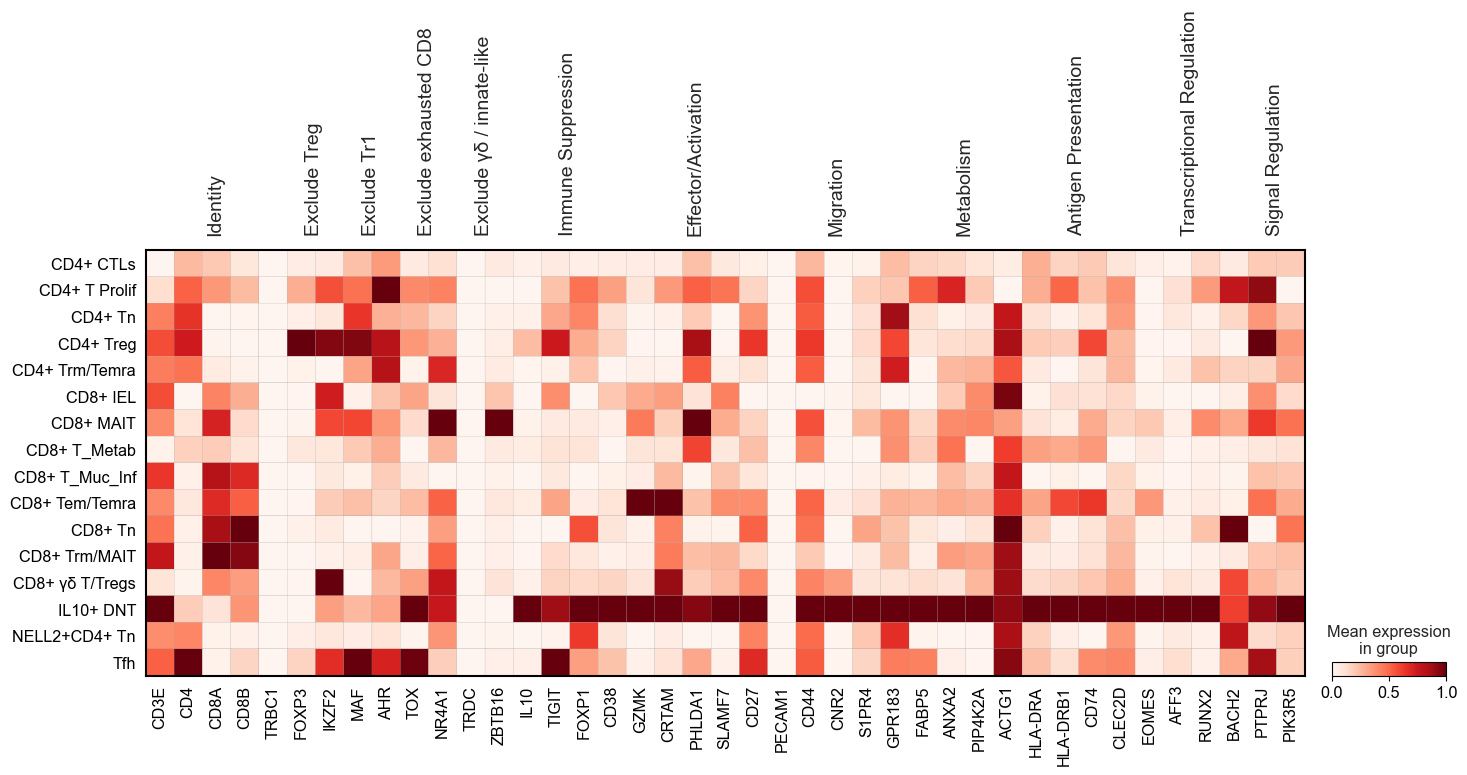

In [58]:
sc.pl.matrixplot(adata = public_4_tadata, var_names = category_dict,groupby = 'subtype',cmap = 'Reds',standard_scale = 'var')

In [63]:
spdata

AnnData object with n_obs × n_vars = 79661 × 19005
    obs: 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', 'orig.ident', 'x', 'y', 'sample', 'chip', 'total_counts_mt', 'total_counts_rp', 'pct_counts_rp', 'n_genes', 'harmony_leiden', 'group', 'batch', 'status', 'sample_2', 'leiden_new', '_indices', '_scvi_batch', '_scvi_labels', 'C1Q+ TR-Macro', 'MERTK+ Macro', 'TNF+Macro', 'FCN1+ Inf-Macro', 'Th17-like', 'Cycling CD4', 'CD4+Tcm-like', 'CD4+ Treg', 'CD4+ Trm', 'γδIEL', 'CD8+MAIT', 'CD8+Trm-MAIT', 'CD8+ Tem', 'CD8+ Tn', 'γδT', 'Epi-interactive CD8', 'CD8+ Trm', 'Immature colonocyte', 'Maturing colonocyte', 'BEST4+ Epi', 'Endothelial', 'Enterocyte', 'B-interactive Epi', 'Surface colonocyte', 'T-interactive Epi', 'EEC', 'Stem cell', 'GC B', 'Goblet', 'Mucosal-barrier PC', 'ILC', 'Immature pericyte', 'Proliferating Plasmablasts', 'iFib', 'Inf Mono', 'LAMP3+ DC', 'Mast', 'Mature pericyte', 'Epithelial-interface PC', 'Memory B', 'T-interactive PC', 'mFib', 'NK', 'Naive B', 'CD4+ Tn', '

In [64]:
celltypecol = ['C1Q+ TR-Macro', 'MERTK+ Macro', 'TNF+Macro', 'FCN1+ Inf-Macro', 'Th17-like', 'Cycling CD4', 'CD4+Tcm-like', 'CD4+ Treg', 'CD4+ Trm', 'γδIEL', 'CD8+MAIT', 'CD8+Trm-MAIT', 'CD8+ Tem', 'CD8+ Tn', 'γδT', 'Epi-interactive CD8', 'CD8+ Trm', 'Immature colonocyte', 'Maturing colonocyte', 'BEST4+ Epi', 'Endothelial', 'Enterocyte', 'B-interactive Epi', 'Surface colonocyte', 'T-interactive Epi', 'EEC', 'Stem cell', 'GC B', 'Goblet', 'Mucosal-barrier PC', 'ILC', 'Immature pericyte', 'Proliferating Plasmablasts', 'iFib', 'Inf Mono', 'LAMP3+ DC', 'Mast', 'Mature pericyte', 'Epithelial-interface PC', 'Memory B', 'T-interactive PC', 'mFib', 'NK', 'Naive B', 'CD4+ Tn', 'Neural', 'Neutrophil', 'Paneth', 'Prolif GC B', 'Mature PC', 'Activated PC', 'ADAMDEC1+ Fib', 'Subepithelial mFib', 'TA', 'Tfh', 'CXCL12+ Fib', 'Tuft', 'cDC', 'IL10+ DNT', 'pDC']

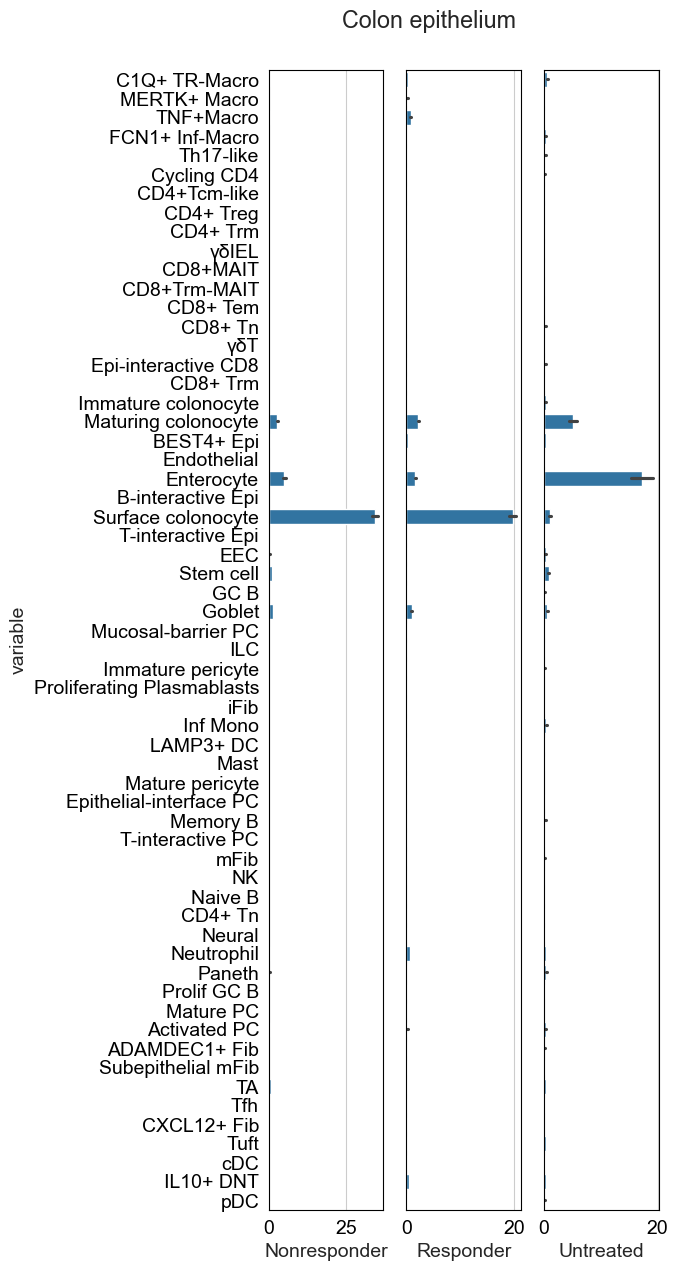

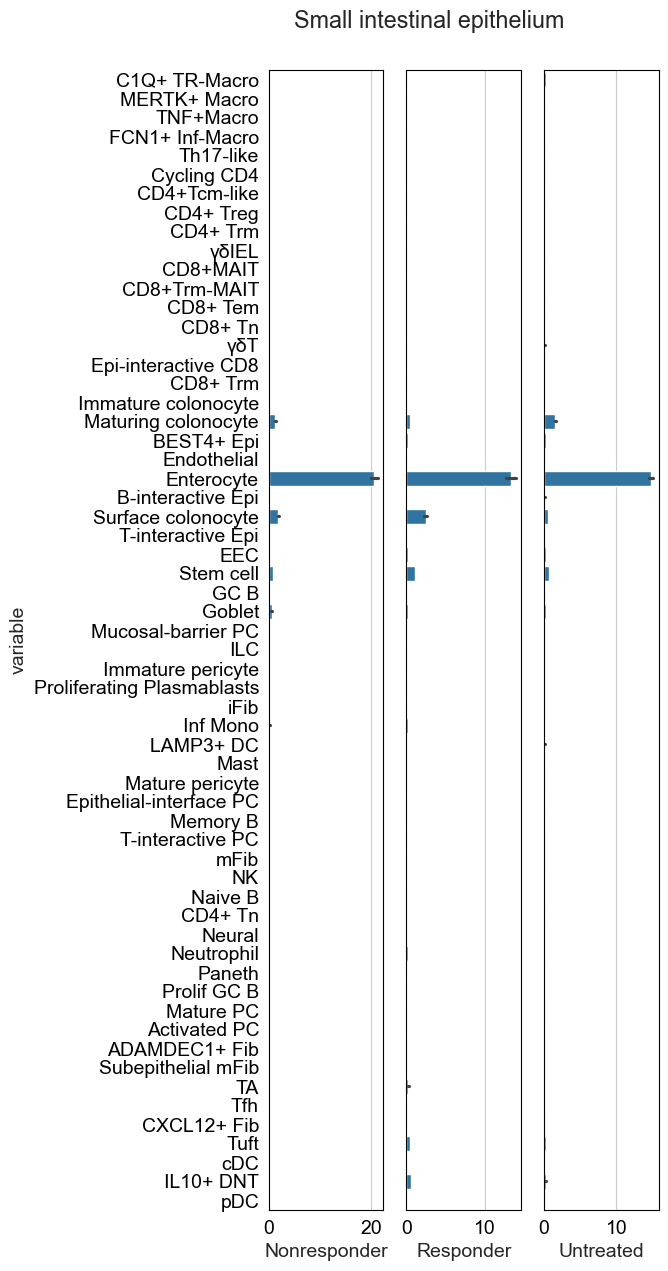

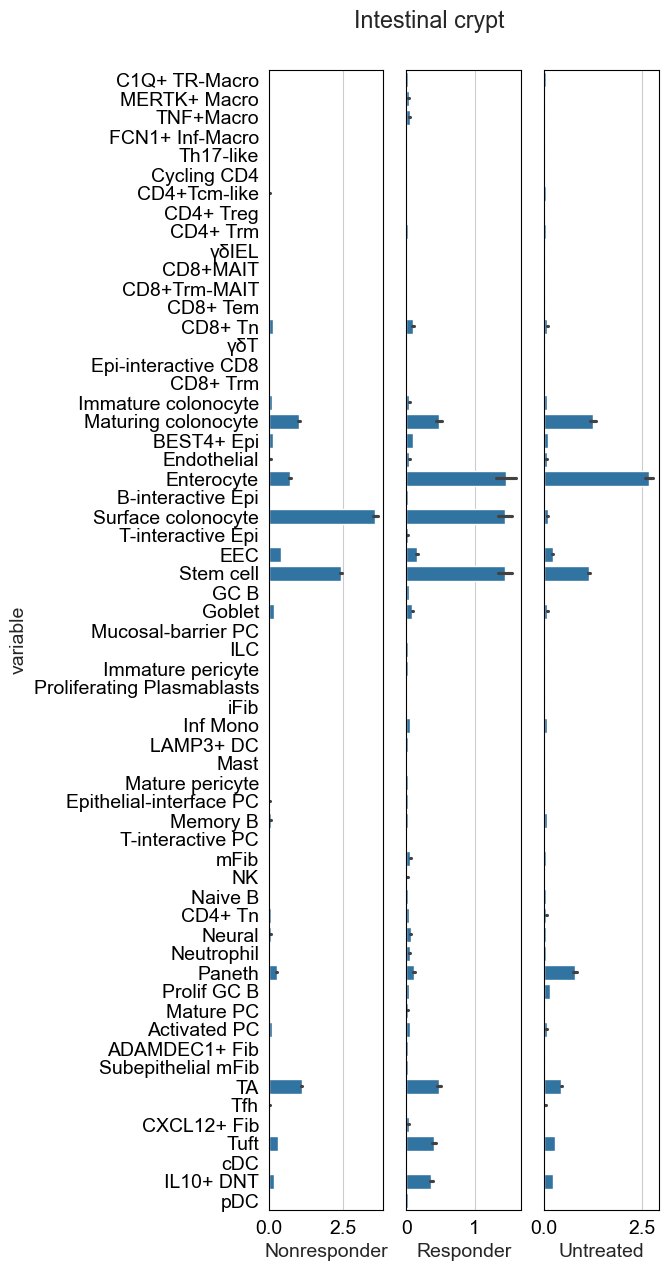

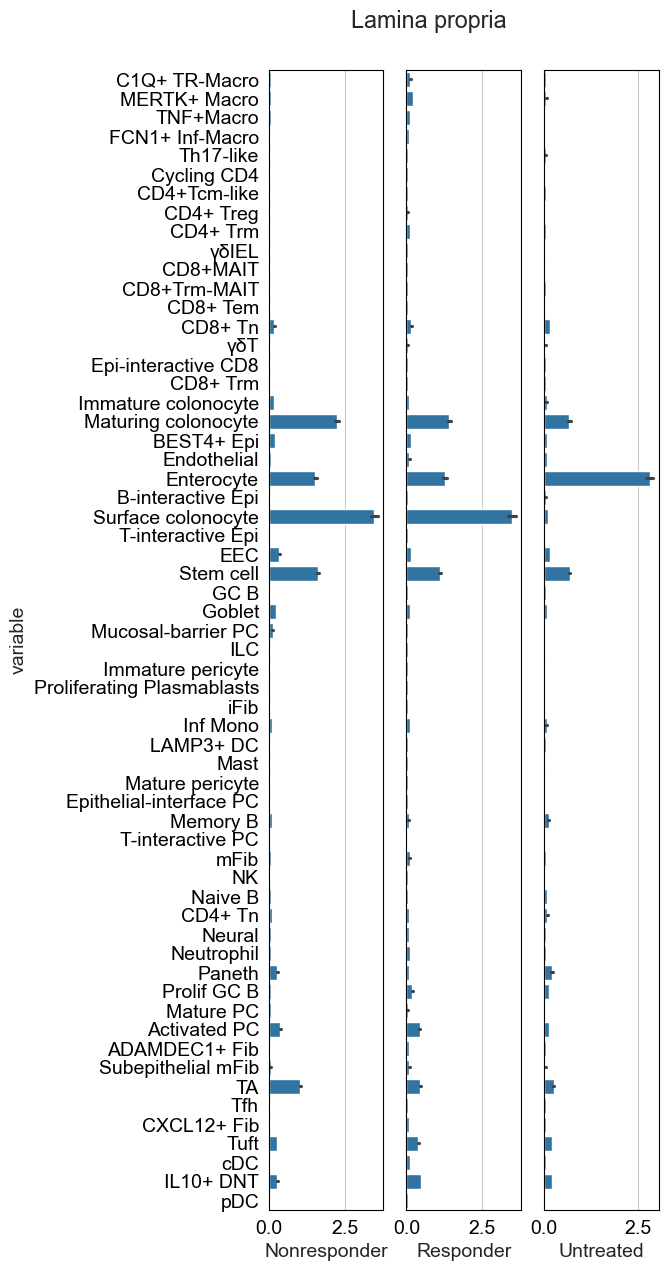

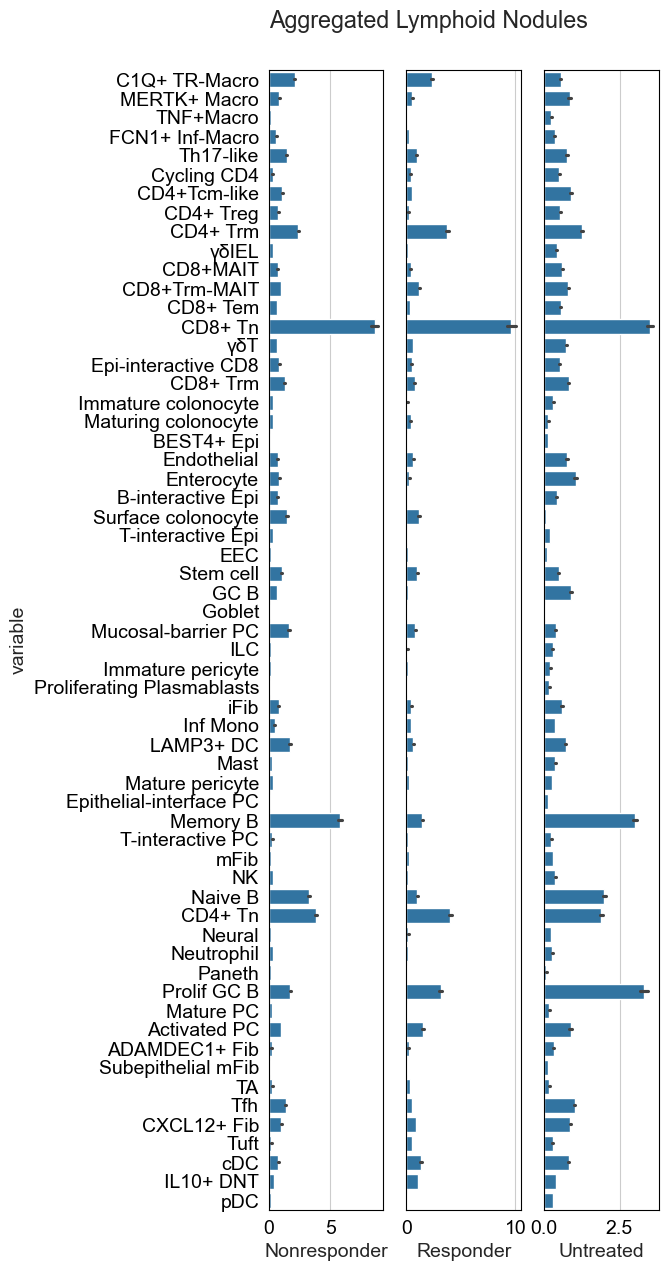

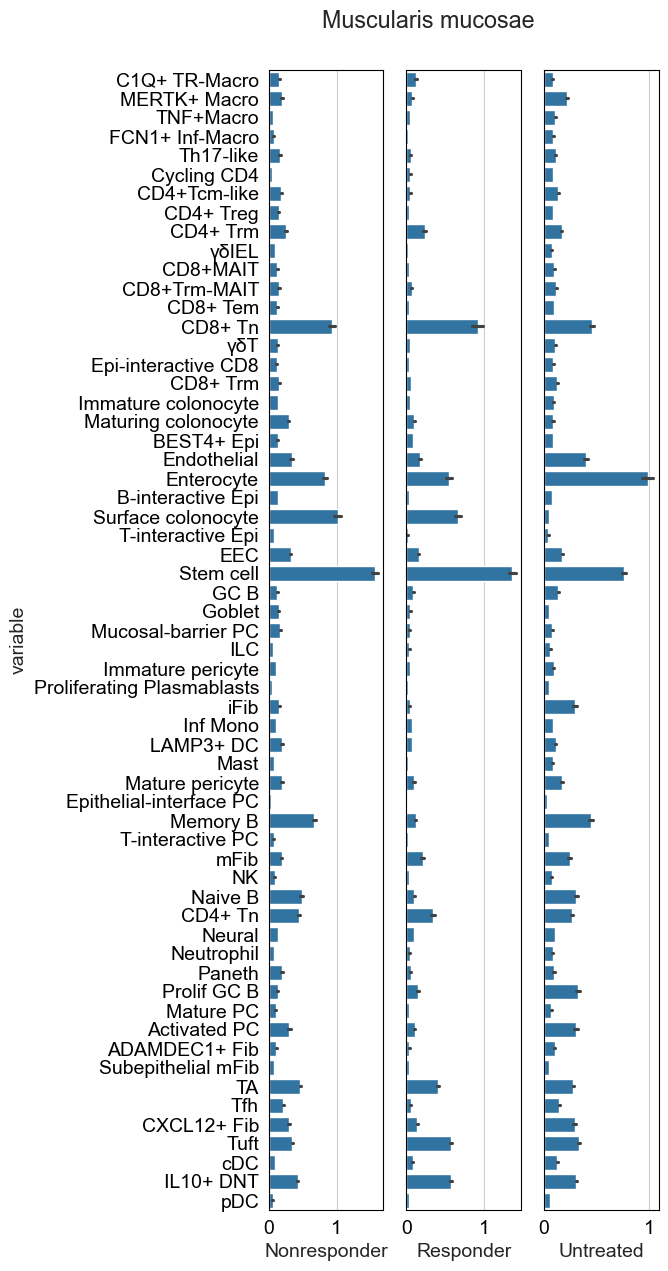

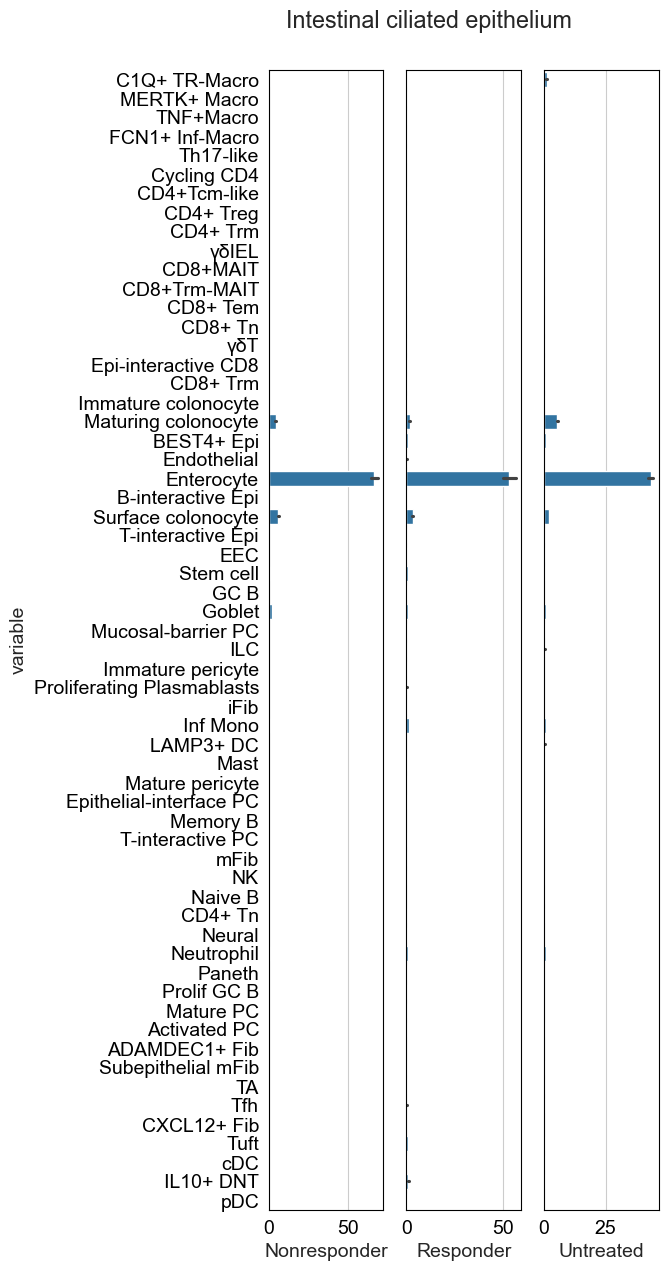

In [65]:
for tissuename in spdata.obs['tissue'].unique():
    subadata = spdata[spdata.obs['tissue'] == tissuename]
    
    fig,axs = plt.subplots(1,3,figsize = (5,15),sharey=True)
    fig.suptitle(tissuename, y=0.95)   # y 可微调
    for idx,groupname in enumerate(spdata.obs['group'].unique()):
        groupadata = subadata[subadata.obs['group'] == groupname]
        tmpdf = groupadata.obs[celltypecol].melt()
        sns.barplot(data = tmpdf ,x = 'value',y = 'variable',ax = axs[idx])
        axs[idx].set_xlabel(groupname)
    fig.show()

/tmp/ipykernel_2175203/3780285771.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  totaltmp = totaltmp.groupby('tissue').mean()


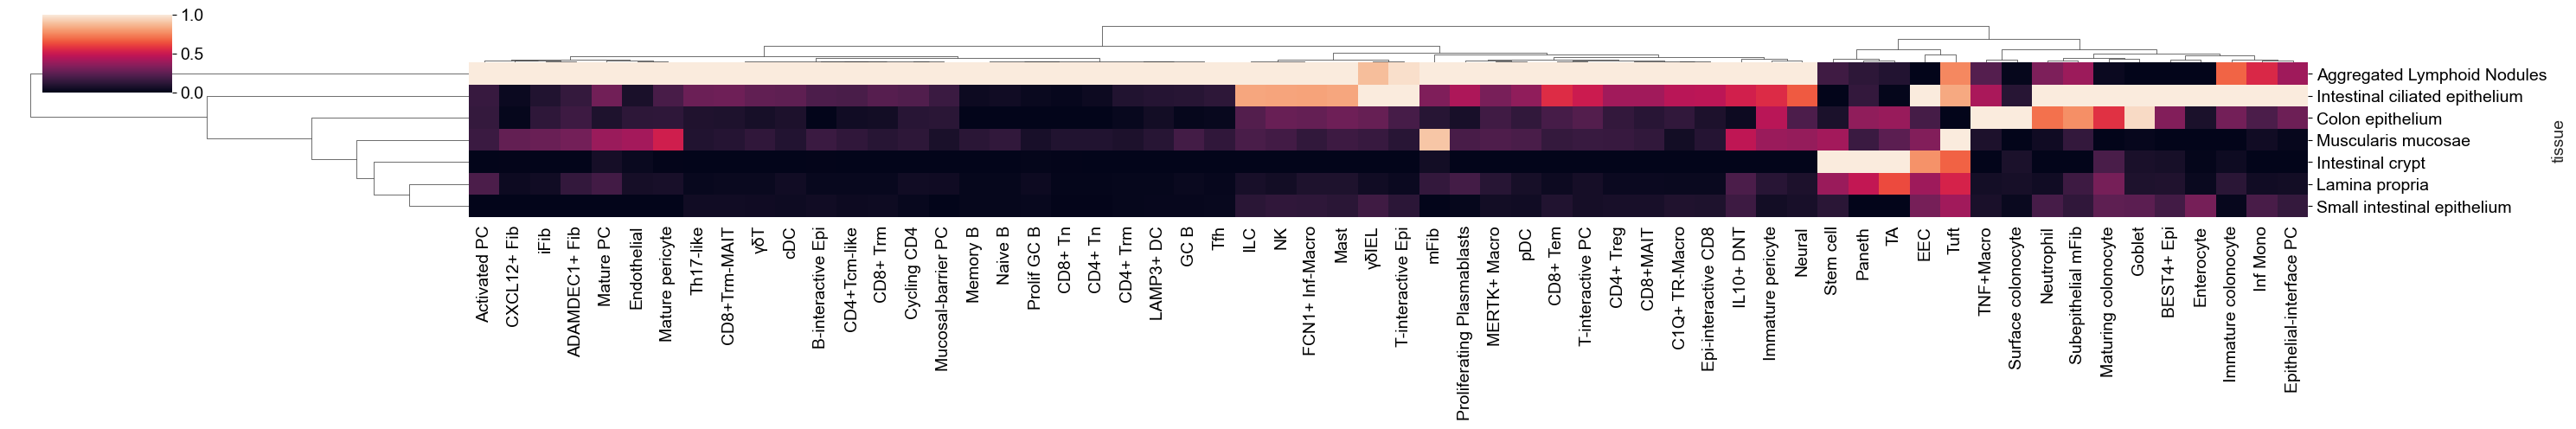

In [68]:
totaltmp = spdata.obs[celltypecol + ['tissue']]
totaltmp = totaltmp.groupby('tissue').mean()
sns.clustermap(totaltmp,method = 'ward',row_cluster = True, col_cluster=True,figsize=(30,5),standard_scale = 1)